# Proyecto 10 - DQN con Stable-Baselines3

Entrenamiento de un agente DQN para `SpaceInvaders-v0` usando Stable-Baselines3.

El notebook mantiene la idea de la práctica anterior:

- imágenes de entrada de 84x84,
- pila de 4 frames,
- red convolucional tipo DQN Atari,
- recompensa clipped,
- conteo de episodios consecutivos con recompensa clipped superior a 20,
- guardado de métricas completas en CSV/JSON, TensorBoard y guardado manual del modelo.


In [1]:
# ============================
# 1. Instalación de librerías
# ============================

# Instalación completa para usar SpaceInvaders-v0 con Gym clásico

%pip install gym==0.17.3
%pip install git+https://github.com/Kojoley/atari-py.git
%pip install stable-baselines3==0.10.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.8 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.17.3-py3-none-any.whl size=1654617 sha256=66f1a5c07afc928d10ca2a3579798211a133199d579fb1762a3f42724d5c85c1
  Stored in directory: /root/.cache/pip/wheels/99/7e/03/69cdeb432380e05bc9a56ff68451d8063e41aa06db508f4be5
Successfully built gym
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.2
    Uninstalling cloudpickle-3.1.2:
      Successfully uninstalled cloudpickle-3.1.2
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.42.0 requires cloudpickl

In [2]:
import gym
from stable_baselines3 import DQN

ENV_ID = "SpaceInvaders-v0"
env = gym.make(ENV_ID)

print("Gym OK")
print("SB3 DQN OK")

Gym OK
SB3 DQN OK


In [3]:
# ============================
# 2. Imports
# ============================

from pathlib import Path
import json
import time
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gym
import torch as th
import torch.nn as nn

from google.colab import drive

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor


In [4]:
# ============================
# 3. Google Drive y rutas
# ============================

drive.mount('/content/gdrive')

drive_root = '/content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo'
PROJECT_NAME = 'sb3_1_spaceinvaders_v0'

OUTPUT_DIR = Path(drive_root) / 'datos' / PROJECT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modelos
MODEL_LATEST = OUTPUT_DIR / 'dqn_spaceinvaders_v0_sb3_latest.zip'
POLICY_LATEST = OUTPUT_DIR / 'dqn_spaceinvaders_v0_policy_latest.pt'

# Logs completos propios
LOG_FILENAME = OUTPUT_DIR / 'dqn_SpaceInvaders-v0_sb3_log.json'
CSV_LOG_FILENAME = OUTPUT_DIR / 'dqn_SpaceInvaders-v0_sb3_log.csv'

# Logs oficiales de SB3
TENSORBOARD_DIR = OUTPUT_DIR / 'tensorboard'
MONITOR_DIR = OUTPUT_DIR / 'monitor'
TENSORBOARD_DIR.mkdir(parents=True, exist_ok=True)
MONITOR_DIR.mkdir(parents=True, exist_ok=True)

print('OUTPUT_DIR:', OUTPUT_DIR)
print('MODEL_LATEST:', MODEL_LATEST)
print('POLICY_LATEST:', POLICY_LATEST)
print('LOG_FILENAME:', LOG_FILENAME)
print('CSV_LOG_FILENAME:', CSV_LOG_FILENAME)
print('TENSORBOARD_DIR:', TENSORBOARD_DIR)
print('MONITOR_DIR:', MONITOR_DIR)


Mounted at /content/gdrive
OUTPUT_DIR: /content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo/datos/sb3_1_spaceinvaders_v0
MODEL_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_sb3_latest.zip
POLICY_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_policy_latest.pt
LOG_FILENAME: /content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo/datos/sb3_1_spaceinvaders_v0/dqn_SpaceInvaders-v0_sb3_log.json
CSV_LOG_FILENAME: /content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo/datos/sb3_1_spaceinvaders_v0/dqn_SpaceInvaders-v0_sb3_log.csv
TENSORBOARD_DIR: /content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo/datos/sb3_1_spaceinvaders_v0/tensorboard
MONITOR_DIR: /content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo/datos/sb3_1_spaceinvaders_v0/monitor


In [8]:
# ============================
# 4. Parámetros principales
# ============================

ENV_ID = 'SpaceInvaders-v0'
SEED = 42

TOTAL_TIMESTEPS = 10_000_000

LEARNING_RATE = 1e-4
BUFFER_SIZE = 100_000
LEARNING_STARTS = 50_000
BATCH_SIZE = 32
GAMMA = 0.99
TRAIN_FREQ = 4
TARGET_UPDATE_INTERVAL = 10_000

EXPLORATION_INITIAL_EPS = 1.0
EXPLORATION_FINAL_EPS = 0.001
EXPLORATION_FRACTION = 0.30

CONSECUTIVE_THRESHOLD = 20.0
TARGET_CONSECUTIVE_EPISODES = 100

SAVE_FREQ_STEPS = 100_000
PRINT_EVERY_EPISODES = 10

LOAD_MODEL = False


In [11]:
# ============================
# 5. Comprobación del entorno
# ============================
# Si SpaceInvaders-v0 no existe en el entorno de Colab, esta celda dará error.

test_env = gym.make(ENV_ID)
print('Entorno creado correctamente:', ENV_ID)
print('Action space:', test_env.action_space)
print('Observation space:', test_env.observation_space)
test_env.close()


Entorno creado correctamente: SpaceInvaders-v0
Action space: Discrete(6)
Observation space: Box(0, 255, (210, 160, 3), uint8)


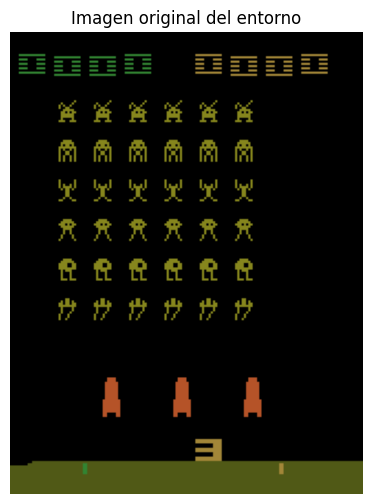

In [12]:
# ============================
# 6. Mostrar imagen original del entorno
# ============================

def reset_env_compat(env):
    result = env.reset()
    if isinstance(result, tuple):
        return result[0]
    return result

raw_env = gym.make(ENV_ID)
obs = reset_env_compat(raw_env)

try:
    frame_rgb = raw_env.render(mode='rgb_array')
except TypeError:
    frame_rgb = raw_env.render()

plt.figure(figsize=(6, 6))
plt.imshow(frame_rgb)
plt.title('Imagen original del entorno')
plt.axis('off')
plt.show()

raw_env.close()


In [13]:
# ============================
# 7. Crear entorno vectorizado para SB3
# ============================
# make_atari_env aplica los wrappers habituales de Atari.
# clip_reward=True hace que la recompensa sea clipped [-1, 0, 1].
# VecFrameStack apila 4 imágenes consecutivas.

def create_env():
    env = make_atari_env(
        ENV_ID,
        n_envs=1,
        seed=SEED,
        monitor_dir=str(OUTPUT_DIR / 'monitor'),
        wrapper_kwargs=dict(clip_reward=True)
    )
    env = VecFrameStack(env, n_stack=4)
    return env

env = create_env()
print('Observation space SB3:', env.observation_space)
print('Action space SB3:', env.action_space)

Observation space SB3: Box(0, 255, (84, 84, 4), uint8)
Action space SB3: Discrete(6)


Shape observación: (1, 84, 84, 4)


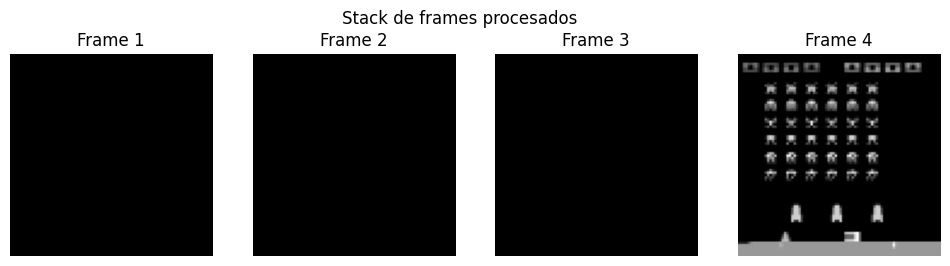

In [14]:
# ============================
# 8. Mostrar imágenes procesadas 84x84 y stack de frames
# ============================

obs = env.reset()
print('Shape observación:', obs.shape)

# Normalmente con CnnPolicy/SB3 queda en formato: (n_envs, channels, height, width)
obs0 = obs[0]

if obs0.shape[0] in [1, 3, 4, 12]:
    # channels first
    frames = obs0
else:
    # channels last
    frames = np.transpose(obs0, (2, 0, 1))

num_frames = min(4, frames.shape[0])

plt.figure(figsize=(12, 3))
for i in range(num_frames):
    plt.subplot(1, num_frames, i + 1)
    plt.imshow(frames[i], cmap='gray')
    plt.title(f'Frame {i + 1}')
    plt.axis('off')
plt.suptitle('Stack de frames procesados')
plt.show()


In [15]:
# ============================
# 9. Red convolucional personalizada 84x84
# ============================
# Arquitectura tipo DQN Atari:
# Entrada: 4 x 84 x 84
# Conv2D 32 filtros 8x8 stride 4
# Conv2D 64 filtros 4x4 stride 2
# Conv2D 64 filtros 3x3 stride 1
# Capa densa de 512 características

class CustomCNN84(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=512):
        super().__init__(observation_space, features_dim)

        n_input_channels = observation_space.shape[0]

        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten()
        )

        with th.no_grad():
            sample = th.as_tensor(observation_space.sample()[None]).float()
            n_flatten = self.cnn(sample).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        return self.linear(self.cnn(observations))

policy_kwargs = dict(
    features_extractor_class=CustomCNN84,
    features_extractor_kwargs=dict(features_dim=512),
    net_arch=[]
)


In [16]:
# ============================
# 9. Función auxiliar de guardado
# ============================
# Esta función solo se usa como alternativa si model.save(...) falla por problemas
# de serialización en Colab/Python. El logger oficial será el de SB3/TensorBoard.

def save_policy_checkpoint(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    th.save(
        {
            "policy_state_dict": model.policy.state_dict(),
            "optimizer_state_dict": model.policy.optimizer.state_dict(),
            "num_timesteps": model.num_timesteps,
            "exploration_rate": getattr(model, "exploration_rate", None),
        },
        path
    )


In [17]:
# ============================
# 10. Logger completo y callback personalizado
# ============================
# Guarda todas las métricas propias en JSON y CSV.
# Además registra métricas custom en TensorBoard/SB3.

class SB3TrainingLogger:
    def __init__(self, json_path, csv_path):
        self.json_path = Path(json_path)
        self.csv_path = Path(csv_path)
        self.json_path.parent.mkdir(parents=True, exist_ok=True)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)

        if self.json_path.exists():
            with open(self.json_path, 'r') as f:
                self.data = json.load(f)
            print('Log JSON previo cargado:', self.json_path)
        else:
            self.data = {
                'episode': [],
                'total_steps': [],
                'episode_reward': [],
                'clipped_episode_reward': [],
                'consecutive_clipped_over_20': [],
                'max_consecutive_clipped_over_20': [],
                'avg_clip50': [],
                'duration': [],
                'exploration_rate': []
            }

    def add_episode(self, episode, total_steps, reward, clipped_reward,
                    consecutive, max_consecutive, avg_clip50, duration,
                    exploration_rate):
        row = {
            'episode': int(episode),
            'total_steps': int(total_steps),
            'episode_reward': float(reward),
            'clipped_episode_reward': float(clipped_reward),
            'consecutive_clipped_over_20': int(consecutive),
            'max_consecutive_clipped_over_20': int(max_consecutive),
            'avg_clip50': float(avg_clip50),
            'duration': float(duration),
            'exploration_rate': float(exploration_rate) if exploration_rate is not None else np.nan
        }

        for key, value in row.items():
            self.data[key].append(value)

        # CSV incremental: se guarda en cada episodio para no perder información si Colab se corta.
        pd.DataFrame([row]).to_csv(
            self.csv_path,
            mode='a',
            header=not self.csv_path.exists(),
            index=False
        )

    def save_json(self):
        with open(self.json_path, 'w') as f:
            json.dump(self.data, f, indent=2)

    def __len__(self):
        return len(self.data.get('episode', []))


class ConsecutiveRewardCallback(BaseCallback):
    def __init__(self, training_logger, verbose=0):
        super().__init__(verbose)
        self.training_logger = training_logger
        self.episode = len(training_logger)
        self.consecutive = 0
        self.max_consecutive = 0
        self.recent_clipped_rewards = deque(maxlen=50)
        self.start_time = time.time()
        self.last_json_save_step = 0

        previous_clipped = training_logger.data.get('clipped_episode_reward', [])[-50:]
        for value in previous_clipped:
            self.recent_clipped_rewards.append(float(value))

        previous_consec = training_logger.data.get('consecutive_clipped_over_20', [])
        if len(previous_consec) > 0:
            self.consecutive = int(previous_consec[-1])

        previous_max = training_logger.data.get('max_consecutive_clipped_over_20', [])
        if len(previous_max) > 0:
            self.max_consecutive = int(max(previous_max))

    def _on_step(self) -> bool:
        infos = self.locals.get('infos', [])

        for info in infos:
            if 'episode' not in info:
                continue

            ep_reward = float(info['episode']['r'])

            # Métrica comparable con tu práctica anterior.
            # En esta configuración SB3 informa reward real; para Space Invaders se usa /10.
            clipped_reward = ep_reward / 10.0

            duration = time.time() - self.start_time
            self.start_time = time.time()

            self.recent_clipped_rewards.append(clipped_reward)

            if clipped_reward > CONSECUTIVE_THRESHOLD:
                self.consecutive += 1
            else:
                self.consecutive = 0

            if self.consecutive > self.max_consecutive:
                self.max_consecutive = self.consecutive

            avg_clip50 = (
                float(np.mean(self.recent_clipped_rewards))
                if len(self.recent_clipped_rewards) > 0
                else 0.0
            )

            exploration_rate = getattr(self.model, 'exploration_rate', np.nan)

            self.training_logger.add_episode(
                episode=self.episode,
                total_steps=self.num_timesteps,
                reward=ep_reward,
                clipped_reward=clipped_reward,
                consecutive=self.consecutive,
                max_consecutive=self.max_consecutive,
                avg_clip50=avg_clip50,
                duration=duration,
                exploration_rate=exploration_rate
            )

            # Métricas personalizadas para TensorBoard/SB3.
            self.logger.record('custom/clipped_episode_reward', clipped_reward)
            self.logger.record('custom/consecutive_clipped_over_20', self.consecutive)
            self.logger.record('custom/max_consecutive_clipped_over_20', self.max_consecutive)
            self.logger.record('custom/avg_clip50', avg_clip50)

            if self.episode % PRINT_EVERY_EPISODES == 0:
                print(
                    f'EP={self.episode:,} | '
                    f'STEP={self.num_timesteps:,} | '
                    f'clip={clipped_reward:.0f} | '
                    f'consec={self.consecutive} | '
                    f'max_consec={self.max_consecutive} | '
                    f'avg_clip50={avg_clip50:.2f}'
                )

            self.episode += 1

            if self.max_consecutive >= TARGET_CONSECUTIVE_EPISODES:
                print('Objetivo conseguido: 100 episodios consecutivos superando el umbral.')
                self.training_logger.save_json()
                return False

        if self.num_timesteps - self.last_json_save_step >= SAVE_FREQ_STEPS:
            self.training_logger.save_json()
            self.last_json_save_step = self.num_timesteps

        return True

    def _on_training_end(self):
        self.training_logger.save_json()
        print('Entrenamiento finalizado.')
        print('max_consec alcanzado:', self.max_consecutive)
        print('Log JSON:', LOG_FILENAME)
        print('Log CSV:', CSV_LOG_FILENAME)


In [18]:
# ============================
# 11. Crear o cargar modelo DQN
# ============================

if LOAD_MODEL and MODEL_LATEST.exists():
    print("Cargando modelo desde:", MODEL_LATEST)

    model = DQN.load(
        str(MODEL_LATEST),
        env=env,
        device="auto",
        tensorboard_log=str(TENSORBOARD_DIR)
    )

    print("Modelo cargado correctamente.")

else:
    print("Creando modelo nuevo.")

    model = DQN(
        policy="CnnPolicy",
        env=env,
        learning_rate=LEARNING_RATE,
        buffer_size=BUFFER_SIZE,
        learning_starts=LEARNING_STARTS,
        batch_size=BATCH_SIZE,
        gamma=GAMMA,
        train_freq=TRAIN_FREQ,
        target_update_interval=TARGET_UPDATE_INTERVAL,
        exploration_initial_eps=EXPLORATION_INITIAL_EPS,
        exploration_final_eps=EXPLORATION_FINAL_EPS,
        exploration_fraction=EXPLORATION_FRACTION,
        policy_kwargs=policy_kwargs,
        tensorboard_log=str(TENSORBOARD_DIR),
        verbose=1,
        seed=SEED,
        device="auto"
    )

    print("Modelo nuevo creado correctamente.")

print("Política usada:")
print(model.policy)


Creando modelo nuevo.
Using cuda device
Wrapping the env in a VecTransposeImage.
Modelo nuevo creado correctamente.
Política usada:
CnnPolicy(
  (q_net): QNetwork(
    (features_extractor): CustomCNN84(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
        (3): ReLU()
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
        (5): ReLU()
        (6): Flatten(start_dim=1, end_dim=-1)
      )
      (linear): Sequential(
        (0): Linear(in_features=3136, out_features=512, bias=True)
        (1): ReLU()
      )
    )
    (q_net): Sequential(
      (0): Linear(in_features=512, out_features=6, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): CustomCNN84(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
       

In [ ]:
# ============================
# 12. Entrenamiento
# ============================

training_logger = SB3TrainingLogger(
    json_path=LOG_FILENAME,
    csv_path=CSV_LOG_FILENAME
)

callback = ConsecutiveRewardCallback(
    training_logger=training_logger,
    verbose=1
)

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback,
    reset_num_timesteps=not LOAD_MODEL,
    tb_log_name='DQN_SpaceInvaders_v0',
    log_interval=100
)


Se han truncado las últimas 5000 líneas del flujo de salida.
EP=4,590 | STEP=802,238 | clip=22 | consec=3 | max_consec=8 | avg_clip50=22.83
--------------------------------------
| custom/                 |          |
|    avg_clip50           | 22.8     |
|    clipped_episode_r... | 16.5     |
|    consecutive_clipp... | 0        |
|    max_consecutive_c... | 8        |
| rollout/                |          |
|    ep_len_mean          | 838      |
|    ep_rew_mean          | 225      |
|    exploration rate     | 0.732    |
| time/                   |          |
|    episodes             | 13700    |
|    fps                  | 262      |
|    time_elapsed         | 3057     |
|    total timesteps      | 803356   |
| train/                  |          |
|    learning_rate        | 0.0001   |
|    loss                 | 0.0988   |
|    n_updates            | 188338   |
--------------------------------------
EP=4,600 | STEP=804,242 | clip=3 | consec=0 | max_consec=8 | avg_clip50=21.31
EP

In [ ]:
# ============================
# 13. Guardado manual del modelo
# ============================
# Primero se intenta guardar con SB3. Si falla por serialización ,
# se guarda únicamente la política y el optimizador con PyTorch.

try:
    model.save(str(MODEL_LATEST))
    print('Modelo completo SB3 guardado en:', MODEL_LATEST)

except Exception as e:
    print('No se pudo guardar el modelo completo con SB3.')
    print('Error:', repr(e))
    save_policy_checkpoint(model, POLICY_LATEST)
    print('Política/optimizador guardados con PyTorch en:', POLICY_LATEST)


No se pudo guardar el modelo completo con SB3.
Error: IndexError('tuple index out of range')
Política/optimizador guardados con PyTorch en: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_policy_latest.pt


Filas registradas: 11961
Columnas: ['episode', 'total_steps', 'episode_reward', 'clipped_episode_reward', 'consecutive_clipped_over_20', 'max_consecutive_clipped_over_20', 'avg_clip50', 'duration', 'exploration_rate']


,episode,total_steps,episode_reward,clipped_episode_reward,consecutive_clipped_over_20,max_consecutive_clipped_over_20,avg_clip50,duration,exploration_rate
11951,11921,2630487,525.0,52.5,91,91,60.98,1.602062,0.124048
11952,11922,2630696,595.0,59.5,92,92,61.03,0.948333,0.123979
11953,11923,2631025,520.0,52.0,93,93,60.92,1.414632,0.123869
11954,11924,2631553,1300.0,130.0,94,94,62.58,2.251499,0.123693
11955,11925,2631852,530.0,53.0,95,95,62.64,1.295319,0.123594
11956,11926,2632170,550.0,55.0,96,96,62.54,1.395159,0.123488
11957,11927,2632426,500.0,50.0,97,97,61.22,1.144407,0.123402
11958,11928,2632752,575.0,57.5,98,98,59.75,1.415885,0.123294
11959,11929,2632938,435.0,43.5,99,99,59.42,0.851201,0.123232
11960,11930,2633424,975.0,97.5,100,100,60.29,2.080515,0.123070


,metrica,valor
0,episodios_registrados,1.196100e+04
1,ultimo_step,2.633424e+06
2,mejor_clip,1.580000e+02
3,mejor_avg_clip50,6.361000e+01
4,mejor_max_consec,1.000000e+02
5,ultimo_avg_clip50,6.029000e+01
6,ultimo_exploration_rate,1.230701e-01


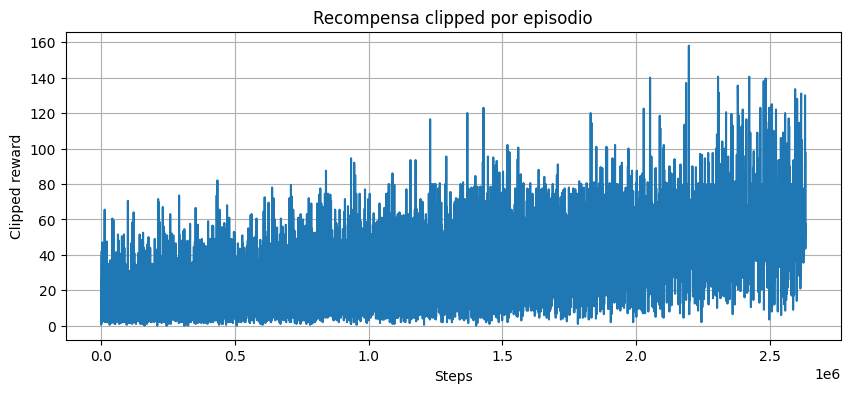

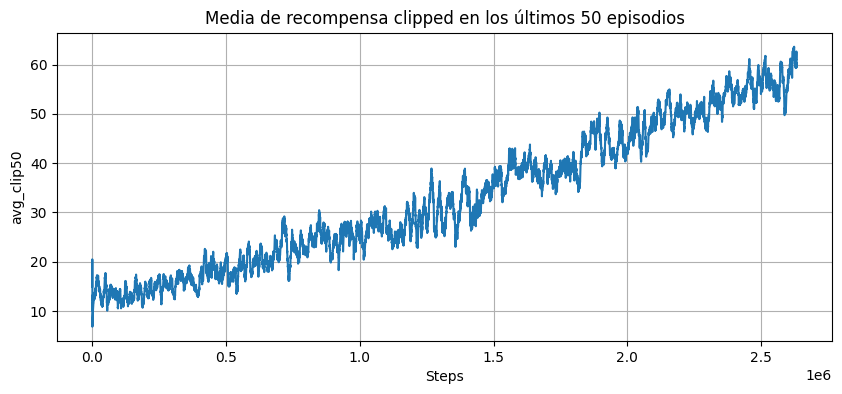

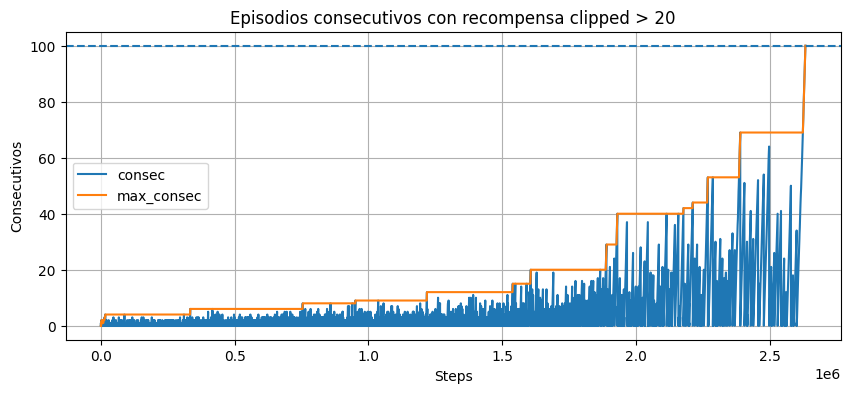

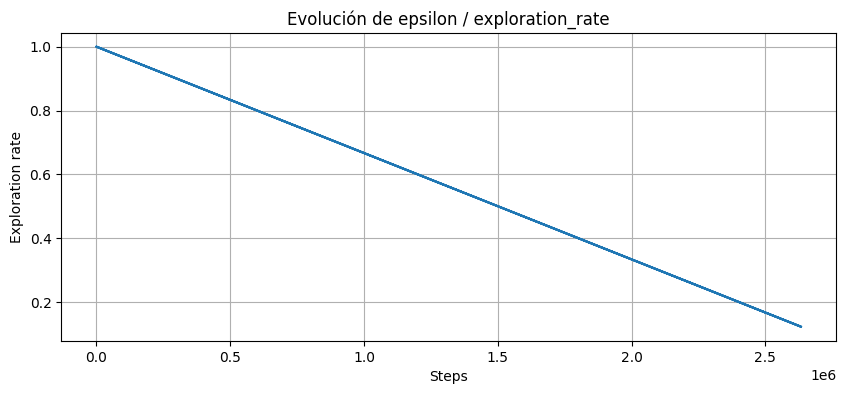

Mejor max_consec: 100
Mejor avg_clip50: 63.61


In [ ]:
# ============================
# 14. Tablas y gráficas del entrenamiento
# ============================

if not CSV_LOG_FILENAME.exists():
    raise FileNotFoundError(f'No existe el log CSV: {CSV_LOG_FILENAME}')

df = pd.read_csv(CSV_LOG_FILENAME)
print('Filas registradas:', len(df))
print('Columnas:', list(df.columns))

display(df.tail(10))

summary_table = pd.DataFrame({
    'metrica': [
        'episodios_registrados',
        'ultimo_step',
        'mejor_clip',
        'mejor_avg_clip50',
        'mejor_max_consec',
        'ultimo_avg_clip50',
        'ultimo_exploration_rate'
    ],
    'valor': [
        len(df),
        int(df['total_steps'].iloc[-1]) if len(df) else 0,
        float(df['clipped_episode_reward'].max()) if len(df) else 0.0,
        float(df['avg_clip50'].max()) if len(df) else 0.0,
        int(df['max_consecutive_clipped_over_20'].max()) if len(df) else 0,
        float(df['avg_clip50'].iloc[-1]) if len(df) else 0.0,
        float(df['exploration_rate'].iloc[-1]) if 'exploration_rate' in df and len(df) else np.nan
    ]
})

display(summary_table)

steps = df['total_steps'].to_numpy()
clipped = df['clipped_episode_reward'].to_numpy()
consec = df['consecutive_clipped_over_20'].to_numpy()
max_consec = df['max_consecutive_clipped_over_20'].to_numpy()
avg50 = df['avg_clip50'].to_numpy()

plt.figure(figsize=(10, 4))
plt.plot(steps, clipped)
plt.title('Recompensa clipped por episodio')
plt.xlabel('Steps')
plt.ylabel('Clipped reward')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(steps, avg50)
plt.title('Media de recompensa clipped en los últimos 50 episodios')
plt.xlabel('Steps')
plt.ylabel('avg_clip50')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(steps, consec, label='consec')
plt.plot(steps, max_consec, label='max_consec')
plt.axhline(TARGET_CONSECUTIVE_EPISODES, linestyle='--')
plt.title('Episodios consecutivos con recompensa clipped > 20')
plt.xlabel('Steps')
plt.ylabel('Consecutivos')
plt.legend()
plt.grid(True)
plt.show()

if 'exploration_rate' in df.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(steps, df['exploration_rate'])
    plt.title('Evolución de epsilon / exploration_rate')
    plt.xlabel('Steps')
    plt.ylabel('Exploration rate')
    plt.grid(True)
    plt.show()

print('Mejor max_consec:', int(max(max_consec)) if len(max_consec) else 0)
print('Mejor avg_clip50:', float(max(avg50)) if len(avg50) else 0.0)


No se pudo cargar MODEL_LATEST. Se usa el modelo actual en memoria.
Error: ValueError("Error: the file <_io.BufferedReader name='/content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_sb3_latest.zip'> wasn't a zip-file")


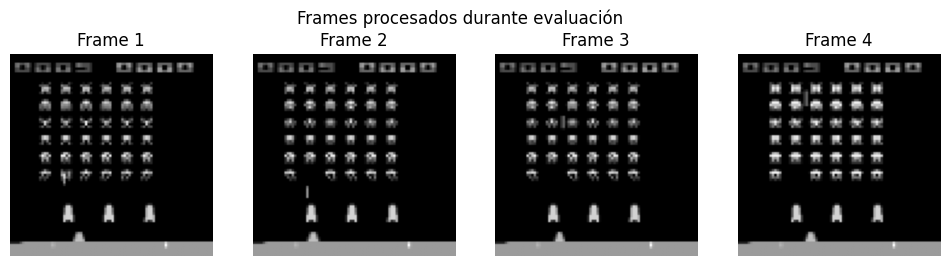

In [ ]:
# ============================
# 15. Evaluación visual rápida
# ============================
# Si existe el modelo completo de SB3, se carga.
# Si no, se usa el modelo actual de memoria.

if MODEL_LATEST.exists():
    try:
        model = DQN.load(str(MODEL_LATEST), env=env, device='auto')
        print('Modelo cargado para evaluación:', MODEL_LATEST)
    except Exception as e:
        print('No se pudo cargar MODEL_LATEST. Se usa el modelo actual en memoria.')
        print('Error:', repr(e))
else:
    print('No existe MODEL_LATEST. Se usa el modelo actual en memoria.')

obs = env.reset()
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

obs0 = obs[0]
if obs0.shape[0] in [1, 3, 4, 12]:
    frames = obs0
else:
    frames = np.transpose(obs0, (2, 0, 1))

num_frames = min(4, frames.shape[0])
plt.figure(figsize=(12, 3))
for i in range(num_frames):
    plt.subplot(1, num_frames, i + 1)
    plt.imshow(frames[i], cmap='gray')
    plt.title(f'Frame {i + 1}')
    plt.axis('off')
plt.suptitle('Frames procesados durante evaluación')
plt.show()


In [ ]:
# ============================
# 16. Cerrar entorno
# ============================

# env.close()


In [ ]:
# ============================
# 17. Comprobación final de ficheros y resultados
# ============================

print('OUTPUT_DIR:', OUTPUT_DIR)
print('Existe OUTPUT_DIR:', OUTPUT_DIR.exists())
print('MODEL_LATEST:', MODEL_LATEST, '| existe:', MODEL_LATEST.exists())
print('POLICY_LATEST:', POLICY_LATEST, '| existe:', POLICY_LATEST.exists())
print('LOG_FILENAME:', LOG_FILENAME, '| existe:', LOG_FILENAME.exists())
print('CSV_LOG_FILENAME:', CSV_LOG_FILENAME, '| existe:', CSV_LOG_FILENAME.exists())
print('TENSORBOARD_DIR:', TENSORBOARD_DIR, '| existe:', TENSORBOARD_DIR.exists())
print('MONITOR_DIR:', MONITOR_DIR, '| existe:', MONITOR_DIR.exists())

if CSV_LOG_FILENAME.exists():
    df_check = pd.read_csv(CSV_LOG_FILENAME)
    print('\nResumen del log CSV')
    print('Episodios registrados:', len(df_check))

    if len(df_check) > 0:
        print('Último episodio:', int(df_check['episode'].iloc[-1]))
        print('Último step:', int(df_check['total_steps'].iloc[-1]))
        print('Mejor clipped_episode_reward:', float(df_check['clipped_episode_reward'].max()))
        print('Mejor avg_clip50:', float(df_check['avg_clip50'].max()))
        print('Mejor max_consec:', int(df_check['max_consecutive_clipped_over_20'].max()))
        print('Último avg_clip50:', float(df_check['avg_clip50'].iloc[-1]))

        display(df_check.tail(5))
else:
    print('\nNo se encontró el CSV de entrenamiento. Ejecuta el bloque de entrenamiento con el callback actualizado.')

if LOG_FILENAME.exists():
    with open(LOG_FILENAME, 'r') as f:
        data_check = json.load(f)
    print('\nResumen del log JSON')
    print('Claves:', list(data_check.keys()))
    print('Episodios en JSON:', len(data_check.get('episode', [])))
else:
    print('\nNo se encontró el JSON de entrenamiento.')

# Listado breve de ficheros creados en la carpeta del proyecto.
print('\nFicheros principales en OUTPUT_DIR:')
for p in sorted(OUTPUT_DIR.glob('*')):
    if p.is_file():
        print(f'- {p.name} ({p.stat().st_size / 1024:.1f} KB)')
    else:
        print(f'- {p.name}/')


OUTPUT_DIR: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0
Existe OUTPUT_DIR: True
MODEL_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_sb3_latest.zip | existe: True
POLICY_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_spaceinvaders_v0_policy_latest.pt | existe: True
LOG_FILENAME: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_SpaceInvaders-v0_sb3_log.json | existe: True
CSV_LOG_FILENAME: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/dqn_SpaceInvaders-v0_sb3_log.csv | existe: True
TENSORBOARD_DIR: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/tensorboard | existe: True
MONITOR_DIR: /content/gdrive/My Drive/08_MIAR/sb3/conlogs/datos/sb3_1_spaceinvaders_v0/monitor | existe: True

Resumen del log CSV
Episodios registrados: 11961
Último episodio: 11930
Último step: 2633424
Mejor clip

,episode,total_steps,episode_reward,clipped_episode_reward,consecutive_clipped_over_20,max_consecutive_clipped_over_20,avg_clip50,duration,exploration_rate
11956,11926,2632170,550.0,55.0,96,96,62.54,1.395159,0.123488
11957,11927,2632426,500.0,50.0,97,97,61.22,1.144407,0.123402
11958,11928,2632752,575.0,57.5,98,98,59.75,1.415885,0.123294
11959,11929,2632938,435.0,43.5,99,99,59.42,0.851201,0.123232
11960,11930,2633424,975.0,97.5,100,100,60.29,2.080515,0.123070



Resumen del log JSON
Claves: ['episode', 'total_steps', 'episode_reward', 'clipped_episode_reward', 'consecutive_clipped_over_20', 'max_consecutive_clipped_over_20', 'avg_clip50', 'duration', 'exploration_rate']
Episodios en JSON: 11931

Ficheros principales en OUTPUT_DIR:
- dqn_SpaceInvaders-v0_sb3_log.csv (819.1 KB)
- dqn_SpaceInvaders-v0_sb3_log.json (1341.4 KB)
- dqn_spaceinvaders_v0_policy_latest.pt (26381.2 KB)
- dqn_spaceinvaders_v0_sb3_latest.zip (0.0 KB)
- monitor/
- tensorboard/


In [19]:
# ============================
# Entorno de evaluación real
# ============================

import gym
import numpy as np
from stable_baselines3.common.atari_wrappers import (
    MaxAndSkipEnv,
    FireResetEnv,
    WarpFrame
)
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack, VecTransposeImage

def create_eval_env():
    def make_env():
        env = gym.make(ENV_ID)

        env.seed(SEED)
        env = MaxAndSkipEnv(env, skip=4)

        if "FIRE" in env.unwrapped.get_action_meanings():
            env = FireResetEnv(env)

        env = WarpFrame(env)

        return env

    env = DummyVecEnv([make_env])
    env = VecFrameStack(env, n_stack=4)
    env = VecTransposeImage(env)

    return env

In [20]:
# ============================
# Cargar policy aprendida
# ============================

import torch
from stable_baselines3 import DQN

POLICY_LATEST = OUTPUT_DIR / "dqn_spaceinvaders_v0_policy_latest.pt"

eval_env = create_eval_env()

model = DQN(
    policy="CnnPolicy",
    env=eval_env,
    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    gamma=GAMMA,
    train_freq=TRAIN_FREQ,
    target_update_interval=TARGET_UPDATE_INTERVAL,
    exploration_initial_eps=EXPLORATION_INITIAL_EPS,
    exploration_final_eps=EXPLORATION_FINAL_EPS,
    exploration_fraction=EXPLORATION_FRACTION,
    policy_kwargs=policy_kwargs,
    verbose=1,
    seed=SEED,
    device="auto"
)

checkpoint = torch.load(POLICY_LATEST, map_location=model.device)

model.policy.load_state_dict(checkpoint["policy_state_dict"])
model.num_timesteps = checkpoint["num_timesteps"]
model.exploration_rate = checkpoint["exploration_rate"]

print("Policy cargada correctamente")
print("Timesteps:", model.num_timesteps)
print("Exploration rate:", model.exploration_rate)

Using cuda device
Policy cargada correctamente
Timesteps: 2633424
Exploration rate: 0.12307014100000035


In [ ]:
# ============================
# Testing sin entrenamiento
# ============================

TEST_EPISODES = 120

rewards = []
clipped_rewards = []

for ep in range(TEST_EPISODES):
    obs = eval_env.reset()
    done = False
    total_reward = 0.0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, infos = eval_env.step(action)
        total_reward += float(reward[0])
        done = bool(done[0])

    clipped_reward = total_reward / 10.0
    rewards.append(total_reward)
    clipped_rewards.append(clipped_reward)

    print(
        f"TEST EP={ep+1:03d} | "
        f"reward={total_reward:.0f} | "
        f"clip={clipped_reward:.0f}"
    )

print("Reward medio:", np.mean(rewards))
print("Clip medio:", np.mean(clipped_rewards))
print("Reward máximo:", np.max(rewards))
print("Clip máximo:", np.max(clipped_rewards))

eval_env.close()

TEST EP=001 | reward=900 | clip=90
TEST EP=002 | reward=600 | clip=60
TEST EP=003 | reward=575 | clip=58
TEST EP=004 | reward=570 | clip=57
TEST EP=005 | reward=800 | clip=80
TEST EP=006 | reward=600 | clip=60
TEST EP=007 | reward=545 | clip=54
TEST EP=008 | reward=555 | clip=56
TEST EP=009 | reward=360 | clip=36
TEST EP=010 | reward=575 | clip=58
TEST EP=011 | reward=1180 | clip=118
TEST EP=012 | reward=600 | clip=60
TEST EP=013 | reward=575 | clip=58
TEST EP=014 | reward=545 | clip=54
TEST EP=015 | reward=600 | clip=60
TEST EP=016 | reward=915 | clip=92
TEST EP=017 | reward=800 | clip=80
TEST EP=018 | reward=575 | clip=58
TEST EP=019 | reward=600 | clip=60
TEST EP=020 | reward=605 | clip=60
TEST EP=021 | reward=775 | clip=78
TEST EP=022 | reward=575 | clip=58
TEST EP=023 | reward=1295 | clip=130
TEST EP=024 | reward=600 | clip=60
TEST EP=025 | reward=425 | clip=42
TEST EP=026 | reward=1000 | clip=100
TEST EP=027 | reward=605 | clip=60
TEST EP=028 | reward=600 | clip=60
TEST EP=029 | 

## Video de del juego

In [27]:
# ============================
# Grabar una partida en vídeo
# ============================

from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder
from IPython.display import display
import shutil

VIDEO_DIR = OUTPUT_DIR / 'video_1'
if VIDEO_DIR.exists():
    shutil.rmtree(VIDEO_DIR)
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

video_env = make_atari_env(
    ENV_ID,
    n_envs=1,
    seed=SEED,
    wrapper_kwargs=dict(clip_reward=True)
 )
video_env = VecFrameStack(video_env, n_stack=4)
video_env = VecVideoRecorder(
    video_env,
    str(VIDEO_DIR),
    record_video_trigger=lambda step: step == 0,
    video_length=5_000,
    name_prefix='sb3-spaceinvaders'
 )

obs = video_env.reset()
for _ in range(5_000):
    action, _ = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = video_env.step(action)
    if bool(dones[0]):
        break

video_env.close()

video_files = sorted(VIDEO_DIR.glob('*.mp4'))
print('Vídeos generados:', [video_file.name for video_file in video_files])
display(video_files[0] if video_files else 'No se ha generado ningún vídeo.')

Vídeos generados: ['sb3-spaceinvaders-step-0-to-step-5000.mp4']


PosixPath('/content/gdrive/My Drive/08_MIAR/sb3/grupo/A_Refuerzo/datos/sb3_1_spaceinvaders_v0/video_1/sb3-spaceinvaders-step-0-to-step-5000.mp4')

In [28]:
# Reproducir el MP4 generado dentro del notebook
import io
import base64
from IPython.display import HTML

video_files = sorted(VIDEO_DIR.glob('*.mp4'))
if not video_files:
    raise FileNotFoundError(f'No se encontró ningún MP4 en {VIDEO_DIR}')

video_path = video_files[0]
with io.open(video_path, 'r+b') as video_file:
    video = video_file.read()

encoded = base64.b64encode(video).decode('ascii')
HTML(
    data=f'''
    <video width="640" height="auto" alt="space-invaders" controls>
        <source src="data:video/mp4;base64,{encoded}" type="video/mp4" />
    </video>'''
)

In [29]:
# ============================
# Grabar 10 partidas en un único mp4
# ============================

from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder
import shutil

N_EPISODES = 10
MAX_STEPS_PER_EP = 5_000  # margen por episodio, ajusta si Space Invaders dura menos

VIDEO_DIR = OUTPUT_DIR / 'video_10'
if VIDEO_DIR.exists():
    shutil.rmtree(VIDEO_DIR)
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

video_env = make_atari_env(
    ENV_ID,
    n_envs=1,
    seed=SEED,
    wrapper_kwargs=dict(clip_reward=False)
)
video_env = VecFrameStack(video_env, n_stack=4)
video_env = VecVideoRecorder(
    video_env,
    str(VIDEO_DIR),
    record_video_trigger=lambda step: step == 0,
    video_length=N_EPISODES * MAX_STEPS_PER_EP,  # cubre las 10 partidas seguidas
    name_prefix='sb3-spaceinvaders-10eps'
)

obs = video_env.reset()
episodes_done = 0
step = 0
while episodes_done < N_EPISODES:
    action, _ = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = video_env.step(action)
    step += 1
    if bool(dones[0]):
        episodes_done += 1  # el VecEnv ya resetea internamente, obs ya es del nuevo episodio

video_env.close()


In [30]:
# Reproducir el MP4 generado dentro del notebook
import io
import base64
from IPython.display import HTML

video_files = sorted(VIDEO_DIR.glob('*.mp4'))
if not video_files:
    raise FileNotFoundError(f'No se encontró ningún MP4 en {VIDEO_DIR}')

video_path = video_files[0]
with io.open(video_path, 'r+b') as video_file:
    video = video_file.read()

encoded = base64.b64encode(video).decode('ascii')
HTML(
    data=f'''
    <video width="640" height="auto" alt="space-invaders" controls>
        <source src="data:video/mp4;base64,{encoded}" type="video/mp4" />
    </video>'''
)